# Compare Distributions User Study Results Analysis

This notebook analyzes telemetry and accuracy from the **landing_page_compare_distributions** experiment, comparing **list** (raw_outputs) vs **graph** interfaces for the distribution comparison task.

**Filtering**: Only includes participants who visited `landing_page_compare_distributions`, submitted at least one task form, and completed the final Google form (comparing comparisons).

**Metrics**:
- **Accuracy**: % of correct answers per interface (list vs graph)
- **Timing**: Time on task form page (timeOnPageMs) per interface, with loading time subtracted (from `graph_vis_loaded` / `list_vis_loaded`)

**Breakdown**: Both aggregate (across all question types) and per-question-type analysis.

## 1. Setup & Load Data

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.stats import ttest_ind

# Paths: works if run from repo root or from user_study_results/compare_distributions/
DATA_DIR = Path("user_study_results/compare_distributions")
if not DATA_DIR.exists():
    DATA_DIR = Path("compare_distributions")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")

OUTPUTS_PATH = DATA_DIR / "user_study_logging - outputs.csv"
df = pd.read_csv(OUTPUTS_PATH)

def safe_parse_json(s):
    if pd.isna(s) or not isinstance(s, str):
        return []
    try:
        return json.loads(s)
    except json.JSONDecodeError:
        return []

def sem_proportion(p, n):
    if n <= 0: return 0
    return np.sqrt(p * (1 - p) / n)

def pvalue_graph_vs_list(g_vals, l_vals):
    """Independent t-test. Returns p-value or 1.0 if insufficient data."""
    g = [v for v in g_vals if not (isinstance(v, float) and np.isnan(v))]
    l = [v for v in l_vals if not (isinstance(v, float) and np.isnan(v))]
    if len(g) < 2 or len(l) < 2:
        return 1.0
    _, p = ttest_ind(g, l)
    return float(p)

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"Interfaces: {df['Interface'].value_counts().to_dict()}")

Loaded 8532 rows
Columns: ['Timestamp', 'Participant ID', 'Interface', 'Telemetry']
Interfaces: {'graph': 2058, 'raw_outputs': 2052, 'landing_page_compare_distributions': 1432, 'landing_page_single_distribution': 1393, 'landing_page_diversity': 1386, 'graph_untangle': 120, 'landing_page': 88, 'graphs': 3}


## 2. Filter to Compare Distributions Participants

Include participants who visited `landing_page_compare_distributions`, completed the final Google form (comparing comparisons), and are not test users.

In [19]:
filter_test_user = True
TEST_PID_SUBSTRINGS = [
    "690a9d9bf662e714c2edc7df",   # known test user
    "{{%PROLIFIC_PID%}}",         # Prolific URL placeholder
]

compare_rows = df[df['Interface'] == 'landing_page_compare_distributions']
valid_participant_ids = set(
    compare_rows['Participant ID'].dropna().astype(str).str.strip()
) - {''}

if filter_test_user:
    valid_participant_ids = {pid for pid in valid_participant_ids
                            if not any(s in pid for s in TEST_PID_SUBSTRINGS)}

# Filter to participants who completed the final Google form (comparing comparisons)
# Metadata column contains prolific_pid=... for completed submissions; "asdf" or empty = incomplete
COMPARING_PATH = DATA_DIR / "user_study_logging - comparing comparisons.csv"
form_completions = pd.read_csv(COMPARING_PATH)
metadata_col = [c for c in form_completions.columns if "Metadata" in c][0]

def parse_prolific_pid_from_metadata(meta):
    if pd.isna(meta) or not isinstance(meta, str) or meta.strip() == "":
        return None
    if "prolific_pid=" not in meta:
        return None
    for part in meta.split("&"):
        if part.startswith("prolific_pid="):
            return part.split("=", 1)[1].strip()
    return None

completed_prolific_pids = set()
for _, row in form_completions.iterrows():
    pid = parse_prolific_pid_from_metadata(row.get(metadata_col))
    if pid:
        completed_prolific_pids.add(pid)

def participant_prolific_pid(participant_id):
    if pd.isna(participant_id) or not participant_id or str(participant_id).strip() == "":
        return None
    s = str(participant_id).strip()
    return s.split("_")[0] if "_" in s else s

valid_participant_ids = {pid for pid in valid_participant_ids
                        if participant_prolific_pid(pid) in completed_prolific_pids}

# Also include rows with empty Participant ID but session in telemetry (local testing)
# For now we require Participant ID
filtered_df = df[df['Participant ID'].isin(valid_participant_ids)].copy()

# If no valid PIDs, include all landing_page_compare_distributions rows for exploration
if len(filtered_df) == 0 and len(compare_rows) > 0:
    filtered_df = compare_rows.copy()
    print("WARNING: No valid Participant IDs; using all landing_page_compare_distributions rows.")

print(f"Participants: {len(valid_participant_ids)}")
print(f"Filtered rows: {len(filtered_df)} (from {len(df)} total)")
print(f"By Interface:\n{filtered_df['Interface'].value_counts()}")

Participants: 40
Filtered rows: 2385 (from 8532 total)
By Interface:
Interface
landing_page_compare_distributions    1249
graph                                  609
raw_outputs                            527
Name: count, dtype: int64


## 3. Extract task_form_submit Events and Answers

Parse telemetry to extract `task_form_submit` events. Each event has:
- `taskNumber`, `dataset`, `visType` (raw_outputs or graph)
- `timeOnPageMs` (total time on form page)
- `answers` (dict of questionId -> {value, groundTruth, correct, questionType?})

Deduplicate: keep the latest task_form_submit per (participant, taskNumber).

In [20]:
# Map question IDs to questionType (for data that may lack questionType in telemetry)
QUESTION_ID_TO_TYPE = {
    'more_whispering_glade': 'name_most_frequent', 'more_crystal_caverns': 'name_most_frequent',
    'more_luminous_glade': 'name_most_frequent', 'more_lumivine': 'name_most_frequent',
    'more_lumigloom': 'name_most_frequent', 'more_luminae_wisp': 'name_most_frequent',
    'name_percentage': 'name_percentage', 'name_percentage_prompt2': 'name_percentage',
    'phrase_listen_hear': 'phrase_most_frequent', 'phrase_carried_wind': 'phrase_most_frequent',
    'phrase_rustling_leaves': 'phrase_most_frequent', 'phrase_legend': 'phrase_most_frequent',
    'phrase_guide_travelers': 'phrase_most_frequent', 'phrase_curse_evil': 'phrase_most_frequent',
    'possible_cyberspace': 'impossible', 'possible_shopping_mall': 'impossible',
    'possible_crystal_cavern': 'impossible', 'possible_forest_clearing': 'impossible',
    'possible_nuclear_plant': 'impossible', 'possible_social_media': 'impossible',
    'possible_lumivine': 'impossible', 'possible_evolved_forest': 'impossible',
    'sentence_likelihood': 'sentence_likelihood',
    'same_distribution': 'same_distribution',
    'overlap_semantic': 'overlap_semantic',
    'unique_to_a': 'unique_to_prompt', 'unique_to_b': 'unique_to_prompt',
    'production_use': 'preference',
}

def infer_question_type(qid):
    return QUESTION_ID_TO_TYPE.get(qid, 'other')

def extract_task_form_submits(df_subset):
    submits = []
    for _, row in df_subset.iterrows():
        pid = str(row.get('Participant ID', '')).strip() if pd.notna(row.get('Participant ID')) else ''
        telemetry = safe_parse_json(row.get('Telemetry', ''))
        for evt in telemetry:
            if evt.get('type') != 'task_form_submit':
                continue
            data = evt.get('data', {})
            submits.append({
                'participant_id': pid,
                'timestamp': evt.get('timestamp'),
                'taskNumber': data.get('taskNumber'),
                'dataset': data.get('dataset'),
                'visType': data.get('visType'),
                'timeOnPageMs': data.get('timeOnPageMs'),
                'answers': data.get('answers', {}),
            })
    return submits

all_submits = extract_task_form_submits(filtered_df)

# Deduplicate: keep latest per (participant_id, taskNumber)
submits_by_key = {}
for s in all_submits:
    key = (s['participant_id'], s['taskNumber'])
    if key not in submits_by_key or (s['timestamp'] or 0) > (submits_by_key[key]['timestamp'] or 0):
        submits_by_key[key] = s

submits = list(submits_by_key.values())
print(f"Extracted {len(all_submits)} task_form_submit events, {len(submits)} unique (participant, task)")

Extracted 844 task_form_submit events, 80 unique (participant, task)


In [21]:
# Flatten to one row per (participant, taskNumber, questionId)
rows = []
for s in submits:
    vis_type = s['visType']
    condition = 'list' if vis_type == 'raw_outputs' else 'graph'
    time_ms = s.get('timeOnPageMs')
    n_questions = 0
    for qid, ans in (s.get('answers') or {}).items():
        if qid == 'comments':
            continue
        correct = ans.get('correct')
        if correct is None:
            continue  # preference questions have no ground truth
        qtype = ans.get('questionType') or infer_question_type(qid)
        if qtype in ('unique_to_a', 'unique_to_b'):
            qtype = 'unique_to_prompt'
        rows.append({
            'participant_id': s['participant_id'],
            'taskNumber': s['taskNumber'],
            'dataset': s['dataset'],
            'visType': vis_type,
            'condition': condition,
            'questionId': qid,
            'questionType': qtype,
            'correct': correct,
            'timeOnPageMs': time_ms,
            'value': ans.get('value'),
            'groundTruth': ans.get('groundTruth'),
        })
        n_questions += 1

answers_df = pd.DataFrame(rows)

# Time per question (approximate: total task time / num questions)
if len(answers_df) > 0:
    task_times = answers_df.groupby(['participant_id', 'taskNumber', 'condition'])['timeOnPageMs'].first()
    task_counts = answers_df.groupby(['participant_id', 'taskNumber', 'condition']).size()
    answers_df = answers_df.copy()
    answers_df['timePerQuestionMs'] = answers_df.apply(
        lambda r: r['timeOnPageMs'] / max(1, task_counts.get((r['participant_id'], r['taskNumber'], r['condition']), 1)),
        axis=1
    )

print(f"Flattened to {len(answers_df)} answer rows")
if len(answers_df) > 0:
    print(f"By condition: {answers_df['condition'].value_counts().to_dict()}")
    print(f"By questionType: {answers_df['questionType'].value_counts().to_dict()}")

Flattened to 1360 answer rows
By condition: {'list': 680, 'graph': 680}
By questionType: {'impossible': 320, 'name_most_frequent': 240, 'phrase_most_frequent': 240, 'name_percentage': 160, 'unique_to_prompt': 160, 'sentence_likelihood': 80, 'same_distribution': 80, 'overlap_semantic': 80}


## 3.5 Subtract Loading Time from Timing

Match each task to `graph_vis_loaded` or `list_vis_loaded` (from graph/raw_outputs Interface rows) using `start_task` url. Subtract loading time from `timeOnPageMs` so timing reflects only time spent answering, not waiting for the vis to load.

In [22]:
# Extract loading times (graph_vis_loaded, list_vis_loaded) and start_task url mapping
# Following diversity user study: match by (participant_id, url), use first load per (pid, url)
def extract_loading_and_start_task(df_subset):
    graph_load_events = []  # (pid, url, timestamp, load_ms)
    list_load_events = []
    start_tasks = []  # (pid, taskNumber, url)
    for _, row in df_subset.iterrows():
        pid = str(row.get('Participant ID', '')).strip() if pd.notna(row.get('Participant ID')) else ''
        telemetry = safe_parse_json(row.get('Telemetry', ''))
        if not telemetry:
            continue
        page_loads = [(e.get('timestamp'), e.get('data', {}).get('url', '')) for e in telemetry if e.get('type') == 'page_load']
        page_loads = [(t, u) for t, u in page_loads if t and u]
        for evt in telemetry:
            evt_type = evt.get('type')
            ts = evt.get('timestamp')
            data = evt.get('data', {})
            if evt_type == 'graph_vis_loaded':
                load_ms = data.get('timeSincePageLoadMs', 0)
                url = None
                if page_loads:
                    preceding = [(t, u) for t, u in page_loads if t <= ts] if ts else []
                    url = preceding[-1][1] if preceding else page_loads[0][1]
                if url and load_ms is not None:
                    graph_load_events.append((pid, url, ts or 0, float(load_ms)))
            elif evt_type == 'list_vis_loaded':
                load_ms = data.get('timeSincePageLoadMs', 0)
                url = None
                if page_loads:
                    preceding = [(t, u) for t, u in page_loads if t <= ts] if ts else []
                    url = preceding[-1][1] if preceding else page_loads[0][1]
                if url and load_ms is not None:
                    list_load_events.append((pid, url, ts or 0, float(load_ms)))
            elif evt_type == 'start_task':
                url = data.get('url', '')
                task_num = data.get('taskNumber')
                if url and task_num is not None:
                    start_tasks.append((pid, task_num, url))
    def first_per_pid_url(events):
        events = [(p, u, t, m) for p, u, t, m in events if t is not None]
        events.sort(key=lambda x: x[2])
        first = {}
        for pid, url, _, lms in events:
            key = (pid, url)
            if key not in first:
                first[key] = lms
        return first
    graph_first = first_per_pid_url(graph_load_events)
    list_first = first_per_pid_url(list_load_events)
    start_task_lookup = {}  # (pid, taskNumber) -> url (keep first)
    for pid, tn, url in sorted(start_tasks, key=lambda x: (x[0], x[1])):
        key = (pid, tn)
        if key not in start_task_lookup:
            start_task_lookup[key] = url
    return graph_first, list_first, start_task_lookup

graph_loading, list_loading, start_task_url = extract_loading_and_start_task(filtered_df)

# Build loading lookup per (participant_id, taskNumber) for submits
median_graph = float(np.median(list(graph_loading.values()))) if graph_loading else 0
median_list = float(np.median(list(list_loading.values()))) if list_loading else 0

def get_loading_ms(pid, task_num, vis_type):
    url = start_task_url.get((pid, task_num))
    if not url:
        return median_graph if vis_type == 'graph' else median_list
    key = (pid, url)
    if vis_type == 'graph':
        return graph_loading.get(key, median_graph)
    return list_loading.get(key, median_list)

# Add loadingMs and timeOnPageMs_net to answers_df (per task)
if len(answers_df) > 0:
    task_keys = answers_df.groupby(['participant_id', 'taskNumber', 'condition']).agg(
        timeOnPageMs=('timeOnPageMs', 'first'),
    ).reset_index()
    loading_ms_list = []
    time_net_list = []
    for _, r in task_keys.iterrows():
        vis = 'graph' if r['condition'] == 'graph' else 'raw_outputs'
        load_ms = get_loading_ms(r['participant_id'], r['taskNumber'], vis)
        loading_ms_list.append((r['participant_id'], r['taskNumber'], r['condition'], load_ms))
        net = max(0, (r['timeOnPageMs'] or 0) - load_ms)
        time_net_list.append((r['participant_id'], r['taskNumber'], r['condition'], net))
    load_lookup = {(p, t, c): m for p, t, c, m in loading_ms_list}
    net_lookup = {(p, t, c): m for p, t, c, m in time_net_list}
    answers_df['loadingMs'] = answers_df.apply(
        lambda r: load_lookup.get((r['participant_id'], r['taskNumber'], r['condition']), 0), axis=1)
    answers_df['timeOnPageMs_net'] = answers_df.apply(
        lambda r: net_lookup.get((r['participant_id'], r['taskNumber'], r['condition']), r['timeOnPageMs'] or 0), axis=1)
    task_counts = answers_df.groupby(['participant_id', 'taskNumber', 'condition']).size()
    answers_df['timePerQuestionMs'] = answers_df.apply(
        lambda r: net_lookup.get((r['participant_id'], r['taskNumber'], r['condition']), 0) / max(1, task_counts.get((r['participant_id'], r['taskNumber'], r['condition']), 1)),
        axis=1
    )
    print(f"Loading times: graph {len(graph_loading)} matched, list {len(list_loading)} matched")
    print(f"Median fallback: graph {median_graph:.0f} ms, list {median_list:.0f} ms")
    print(f"Time now uses timeOnPageMs_net (loading subtracted)")
else:
    print("No answers_df; skipping loading subtraction.")

Loading times: graph 39 matched, list 41 matched
Median fallback: graph 9909 ms, list 855 ms
Time now uses timeOnPageMs_net (loading subtracted)


## 4. Aggregate Accuracy and Timing (List vs Graph)

## 5.5 Accuracy by Individual Question

Breakdown of accuracy by each question ID (e.g., more_lumivine, phrase_legend), split by interface.

Accuracy by individual question and interface (dataset | questionId):
condition                                            list  graph
question_key                                                    
user_study_monsters_temp | more_lumigloom           0.778  0.773
user_study_monsters_temp | more_luminae_wisp        0.778  0.773
user_study_monsters_temp | more_lumivine            0.667  0.636
user_study_monsters_temp | name_percentage          0.611  0.455
user_study_monsters_temp | name_percentage_prompt2  0.611  0.455
user_study_monsters_temp | overlap_semantic         0.833  0.818
user_study_monsters_temp | phrase_curse_evil        0.778  0.727
user_study_monsters_temp | phrase_guide_travelers   0.889  0.773
user_study_monsters_temp | phrase_legend            0.722  0.955
user_study_monsters_temp | possible_evolved_forest  0.556  0.727
user_study_monsters_temp | possible_lumivine        0.444  0.545
user_study_monsters_temp | possible_nuclear_plant   0.722  0.409
user_study_monsters_

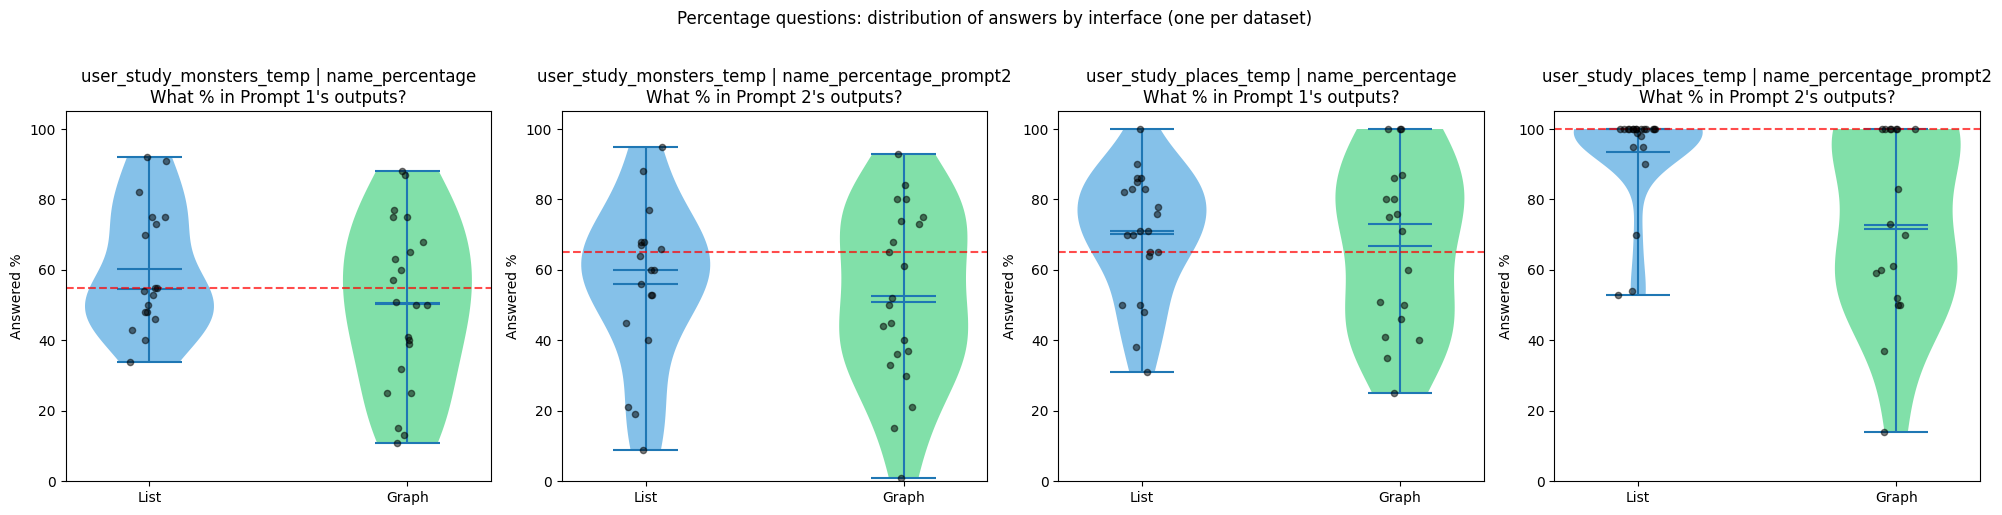

In [23]:
if len(answers_df) == 0:
    print("No data.")
else:
    # Group by (dataset, questionId) so we don't mix questions with different ground truths
    answers_df['question_key'] = answers_df['dataset'] + ' | ' + answers_df['questionId']
    by_qid = answers_df.groupby(['dataset', 'questionId', 'condition']).agg(
        accuracy=('correct', 'mean'),
        sem_accuracy=('correct', lambda x: sem_proportion(x.mean(), len(x))),
        count=('correct', 'count'),
    ).reset_index()

    print("Accuracy by individual question and interface (dataset | questionId):")
    by_qid['question_key'] = by_qid['dataset'] + ' | ' + by_qid['questionId']
    pivot_acc = by_qid.pivot(index='question_key', columns='condition', values='accuracy')
    pivot_acc = pivot_acc.reindex(columns=['list', 'graph'])
    print(pivot_acc.round(3).to_string())

    print("\nCount by individual question and interface:")
    pivot_count = by_qid.pivot(index='question_key', columns='condition', values='count')
    pivot_count = pivot_count.reindex(columns=['list', 'graph'])
    print(pivot_count.to_string())

    # Ground truth and short question label per (questionId, dataset)
    qid_info = answers_df[['questionId', 'dataset', 'groundTruth']].drop_duplicates()
    QUESTION_LABELS = {
        'name_percentage': "What % in Prompt 1's outputs?",
        'name_percentage_prompt2': "What % in Prompt 2's outputs?",
        'more_whispering_glade': "Which set more frequently describes 'The Whispering Glade'?",
        'more_crystal_caverns': "Which set more frequently describes 'The Crystal Caverns'?",
        'more_luminous_glade': "Which set more frequently describes 'The Luminous Glade'?",
        'more_lumivine': "Which set more frequently describes 'Lumivine'?",
        'more_lumigloom': "Which set more frequently describes 'Lumigloom'?",
        'more_luminae_wisp': "Which set more frequently describes 'Luminae Wisp'?",
        'phrase_listen_hear': "Which set more frequently includes 'listen closely can hear'?",
        'phrase_carried_wind': "Which set more frequently includes 'carried by the wind'?",
        'phrase_rustling_leaves': "Which set more frequently includes 'rustling leaves'?",
        'phrase_legend': "Which set more frequently includes 'legend says/tells'?",
        'phrase_guide_travelers': "Which set more frequently describes 'guiding lost travelers'?",
        'phrase_curse_evil': "Which set more frequently describes 'curse, became evil'?",
        'possible_cyberspace': "Possible: 'Digital Nexus in cyberspace'?",
        'possible_shopping_mall': "Possible: 'Grand Bazaar shopping mall'?",
        'possible_crystal_cavern': "Possible: 'Crystal Caverns' description?",
        'possible_forest_clearing': "Possible: 'Whispering Glade' description?",
        'possible_nuclear_plant': "Possible: 'Radiance Wisp in nuclear plant'?",
        'possible_social_media': "Possible: 'Influence Sprite social media'?",
        'possible_lumivine': "Possible: 'Lumivine curse' description?",
        'possible_evolved_forest': "Possible: 'Lumivine guide travelers' description?",
        'sentence_likelihood': "Which prompt more likely generated this sentence?",
        'same_distribution': "Same or different underlying distribution?",
        'overlap_semantic': "Theme/structure shared by both sets?",
        'unique_to_a': "Output unique to Prompt 1?",
        'unique_to_b': "Output unique to Prompt 2?",
    }
    print("\nGround truth and question (dataset | questionId):")
    for (qid, dataset), grp in qid_info.groupby(['questionId', 'dataset']):
        gt = grp['groundTruth'].iloc[0]
        label = QUESTION_LABELS.get(qid, qid)
        print(f"  {dataset} | {qid}: groundTruth={gt}  |  {label}")

    # Violin plots for percentage questions: one subplot per (dataset, questionId)
    pct_df = answers_df[answers_df['questionType'] == 'name_percentage'].copy()
    pct_df['value_num'] = pd.to_numeric(pct_df['value'], errors='coerce')
    pct_df = pct_df[pct_df['value_num'].notna()]
    if len(pct_df) > 0:
        pct_keys = sorted(pct_df.groupby(['dataset', 'questionId']).size().index.tolist())
        n_plots = len(pct_keys)
        fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
        if n_plots == 1:
            axes = [axes]
        colors = ['#3498db', '#2ecc71']
        for ax, (dataset, qid) in zip(axes, pct_keys):
            sub = pct_df[(pct_df['dataset'] == dataset) & (pct_df['questionId'] == qid)]
            list_vals = sub[sub['condition'] == 'list']['value_num'].values
            graph_vals = sub[sub['condition'] == 'graph']['value_num'].values
            parts = ax.violinplot([list_vals, graph_vals], positions=[0, 1], showmeans=True, showmedians=True)
            for i, pc in enumerate(parts['bodies']):
                pc.set_facecolor(colors[i])
                pc.set_alpha(0.6)
            np.random.seed(42)
            for i, (vals, pos) in enumerate(zip([list_vals, graph_vals], [0, 1])):
                jitter = np.random.normal(0, 0.04, size=len(vals))
                ax.scatter(pos + jitter, vals, color='black', alpha=0.5, s=20, zorder=3)
            gt_val = pd.to_numeric(sub['groundTruth'].iloc[0], errors='coerce')
            if not pd.isna(gt_val):
                ax.axhline(gt_val, color='red', linestyle='--', alpha=0.7, label=f'GT={gt_val}')
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['List', 'Graph'])
            ax.set_ylabel('Answered %')
            label = QUESTION_LABELS.get(qid, qid)
            ax.set_title(f'{dataset} | {qid}\n{label}')
            ax.set_ylim(0, 105)
        plt.suptitle('Percentage questions: distribution of answers by interface (one per dataset)', fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()

/Users/emilyreif/Documents/github/llm-consistency-vis/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


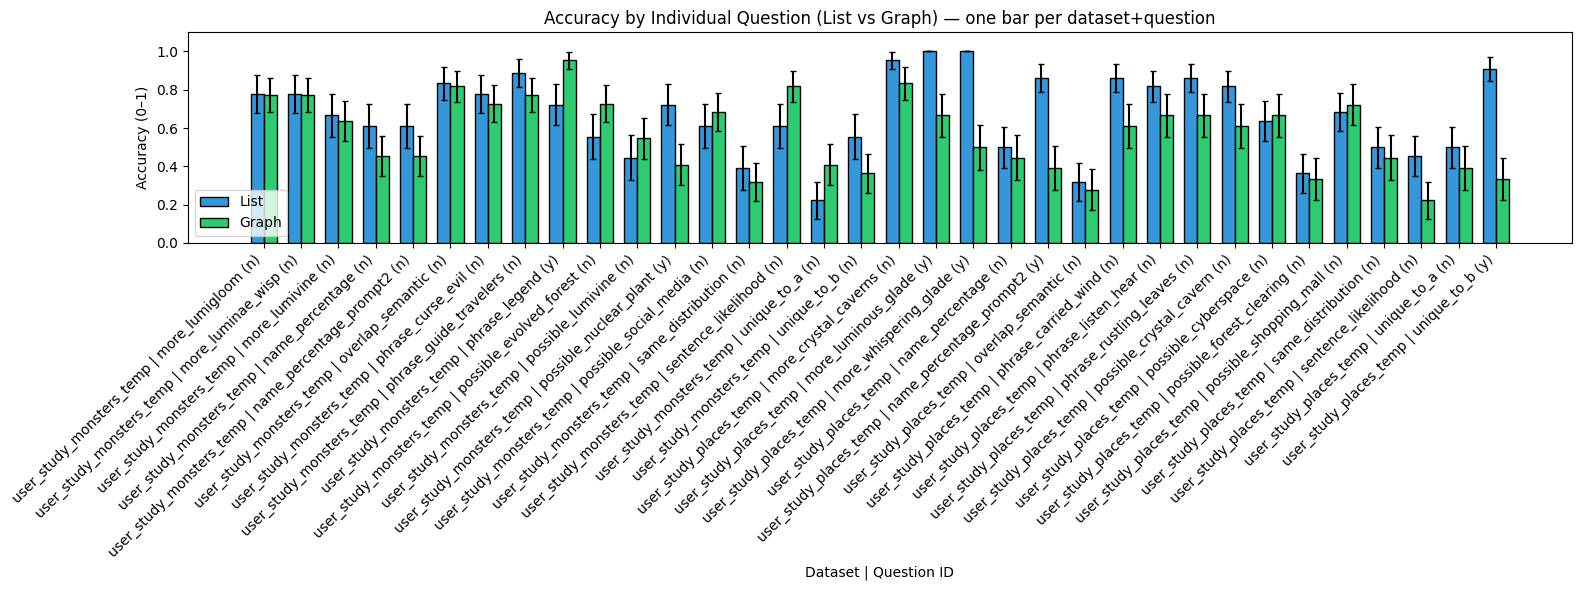

In [24]:
if len(answers_df) == 0:
    print("No data to plot.")
else:
    # Ensure question_key exists (added in cell above)
    if 'question_key' not in answers_df.columns:
        answers_df['question_key'] = answers_df['dataset'] + ' | ' + answers_df['questionId']
    plot_df = answers_df[answers_df['questionType'] != 'preference']
    if len(plot_df) == 0:
        print("No scorable questions.")
    else:
        question_keys = sorted(plot_df['question_key'].unique())
        x = np.arange(len(question_keys))
        width = 0.35

        def acc_and_sem(df, qk, cond):
            sub = df[(df['question_key'] == qk) & (df['condition'] == cond)]
            n = len(sub)
            p = sub['correct'].mean() if n > 0 else 0
            return p, sem_proportion(p, n) if n > 0 else 0

        list_acc = [acc_and_sem(plot_df, qk, 'list')[0] for qk in question_keys]
        graph_acc = [acc_and_sem(plot_df, qk, 'graph')[0] for qk in question_keys]
        list_sem = [acc_and_sem(plot_df, qk, 'list')[1] for qk in question_keys]
        graph_sem = [acc_and_sem(plot_df, qk, 'graph')[1] for qk in question_keys]

        # Per-question p-values (y = significant, n = not)
        p_values_q = [pvalue_graph_vs_list(
            plot_df[(plot_df['question_key'] == qk) & (plot_df['condition'] == 'graph')]['correct'].values,
            plot_df[(plot_df['question_key'] == qk) & (plot_df['condition'] == 'list')]['correct'].values
        ) for qk in question_keys]
        xtick_labels = [f"{qk} (y)" if p < 0.05 else f"{qk} (n)" for qk, p in zip(question_keys, p_values_q)]

        fig, ax = plt.subplots(figsize=(16, 6))
        ax.bar(x - width/2, list_acc, width, yerr=list_sem, label='List', color='#3498db', edgecolor='black', capsize=2)
        ax.bar(x + width/2, graph_acc, width, yerr=graph_sem, label='Graph', color='#2ecc71', edgecolor='black', capsize=2)
        ax.set_xlabel('Dataset | Question ID')
        ax.set_ylabel('Accuracy (0–1)')
        ax.set_title('Accuracy by Individual Question (List vs Graph) — one bar per dataset+question')
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right')
        ax.legend()
        ax.set_ylim(0, 1.1)
        plt.tight_layout()
        plt.show()

### 5.6 Participant Comments ("Any additional comments? (optional)")

In [25]:
# Print responses to "Any additional comments? (optional)" from task forms
comments_list = []
for s in submits:
    ans = s.get('answers') or {}
    comment = ans.get('comments')
    if comment and str(comment).strip():
        comments_list.append({
            'participant_id': s.get('participant_id', ''),
            'taskNumber': s.get('taskNumber'),
            'dataset': s.get('dataset'),
            'condition': 'list' if s.get('visType') == 'raw_outputs' else 'graph',
            'comment': str(comment).strip(),
        })
if not comments_list:
    print("No additional comments provided.")
else:
    print(f"Participant comments ({len(comments_list)} total):\n")
    for c in comments_list:
        print(f"  [{c['participant_id']}] Task {c['taskNumber']} ({c['dataset']}, {c['condition']}):")
        print(f"    \"{c['comment']}\"")
        print()

Participant comments (14 total):

  [698d5b2a97685e002d118f6a_69a8951fbf80ede73bf4f3f0_69a897400d29414b7458a140] Task 1 (user_study_monsters_temp, graph):
    "none"

  [698d5b2a97685e002d118f6a_69a8951fbf80ede73bf4f3f0_69a897400d29414b7458a140] Task 2 (user_study_places_temp, list):
    "none"

  [656c1adbdb298e7230d7b396_69a8951fbf80ede73bf4f3f0_69a89bae4de8f1dd39536c24] Task 1 (user_study_monsters_temp, list):
    "none"

  [656c1adbdb298e7230d7b396_69a8951fbf80ede73bf4f3f0_69a89bae4de8f1dd39536c24] Task 2 (user_study_places_temp, graph):
    "none"

  [697d24efb667eda3edf789ca_69a8951fbf80ede73bf4f3f0_69a89efbfdffdcf8b45a9adb] Task 1 (user_study_places_temp, graph):
    "I like the idea of Whispering instead of Crystal. Thank you for allowing me to participate."

  [697d24efb667eda3edf789ca_69a8951fbf80ede73bf4f3f0_69a89efbfdffdcf8b45a9adb] Task 2 (user_study_monsters_temp, list):
    "This one was difficult to keep track of the differences between the two prompts."

  [699f6aab886

In [26]:
def sem_proportion(p, n):
    if n <= 0: return 0
    return np.sqrt(p * (1 - p) / n)

def sem_mean(x):
    n = len(x)
    return stats.sem(x) if n > 1 else 0

def pvalue_graph_vs_list(g_vals, l_vals):
    g = [v for v in g_vals if not (isinstance(v, float) and np.isnan(v))]
    l = [v for v in l_vals if not (isinstance(v, float) and np.isnan(v))]
    if len(g) < 2 or len(l) < 2:
        return 1.0
    _, p = ttest_ind(g, l)
    return float(p)

if len(answers_df) == 0:
    print("No data to analyze.")
else:
    time_col = 'timeOnPageMs_net' if 'timeOnPageMs_net' in answers_df.columns else 'timeOnPageMs'
    summary = answers_df.groupby('condition').agg(
        accuracy=('correct', 'mean'),
        sem_accuracy=('correct', lambda x: sem_proportion(x.mean(), len(x))),
        mean_time_sec=(time_col, lambda x: x.mean() / 1000),
        sem_time_sec=(time_col, lambda x: sem_mean(x.values / 1000)),
        mean_time_per_q_sec=('timePerQuestionMs', lambda x: x.mean() / 1000),
        count=('correct', 'count'),
    ).reset_index()

    print("Aggregate summary (all question types):")
    print(summary.to_string(index=False))

    # Per-participant scores for t-tests
    acc_by_pid = answers_df.groupby(['participant_id', 'condition'])['correct'].mean().unstack(fill_value=np.nan)
    list_acc = acc_by_pid['list'].dropna().values if 'list' in acc_by_pid.columns else []
    graph_acc = acc_by_pid['graph'].dropna().values if 'graph' in acc_by_pid.columns else []
    p_acc = pvalue_graph_vs_list(graph_acc, list_acc)

    time_col = 'timeOnPageMs_net' if 'timeOnPageMs_net' in answers_df.columns else 'timeOnPageMs'
    time_by_task = answers_df.groupby(['participant_id', 'taskNumber', 'condition'])[time_col].first()
    time_by_pid = time_by_task.reset_index().groupby(['participant_id', 'condition'])[time_col].mean().unstack(fill_value=np.nan) / 1000
    list_time = time_by_pid['list'].dropna().values if 'list' in time_by_pid.columns else []
    graph_time = time_by_pid['graph'].dropna().values if 'graph' in time_by_pid.columns else []
    p_time = pvalue_graph_vs_list(graph_time, list_time)

    print(f"\nT-test (graph vs list): accuracy p={p_acc:.4f}, time p={p_time:.4f}")

Aggregate summary (all question types):
condition  accuracy  sem_accuracy  mean_time_sec  sem_time_sec  mean_time_per_q_sec  count
    graph  0.576471      0.018949     466.150420      9.742821            27.420613    680
     list  0.675000      0.017961     407.905193      8.723402            23.994423    680

T-test (graph vs list): accuracy p=0.0165, time p=0.2891


## 5. Accuracy and Timing by Question Type

In [27]:
if len(answers_df) == 0:
    print("No data.")
else:
    by_qtype = answers_df.groupby(['questionType', 'condition']).agg(
        accuracy=('correct', 'mean'),
        sem_accuracy=('correct', lambda x: sem_proportion(x.mean(), len(x))),
        mean_time_per_q_sec=('timePerQuestionMs', lambda x: x.mean() / 1000),
        count=('correct', 'count'),
    ).reset_index()

    print("Accuracy by question type and interface:")
    pivot_acc = by_qtype.pivot(index='questionType', columns='condition', values='accuracy')
    pivot_acc = pivot_acc.reindex(columns=['list', 'graph'])
    print(pivot_acc.round(3).to_string())

    print("\nCount by question type and interface:")
    pivot_count = by_qtype.pivot(index='questionType', columns='condition', values='count')
    pivot_count = pivot_count.reindex(columns=['list', 'graph'])
    print(pivot_count.to_string())

Accuracy by question type and interface:
condition              list  graph
questionType                      
impossible            0.606  0.588
name_most_frequent    0.875  0.700
name_percentage       0.650  0.438
overlap_semantic      0.550  0.575
phrase_most_frequent  0.825  0.742
same_distribution     0.450  0.375
sentence_likelihood   0.525  0.550
unique_to_prompt      0.562  0.375

Count by question type and interface:
condition             list  graph
questionType                     
impossible             160    160
name_most_frequent     120    120
name_percentage         80     80
overlap_semantic        40     40
phrase_most_frequent   120    120
same_distribution       40     40
sentence_likelihood     40     40
unique_to_prompt        80     80


## 6. Bar Charts: Aggregate Accuracy and Timing

**(y)** = p < 0.05 (significant difference list vs graph); **(n)** = not significant (independent t-test).

### 6.1 Accuracy by Individual Question (dataset | questionId)

Each bar = one distinct question instance (dataset + questionId). Correctness was computed per-answer against that instance's ground truth.

/Users/emilyreif/Documents/github/llm-consistency-vis/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


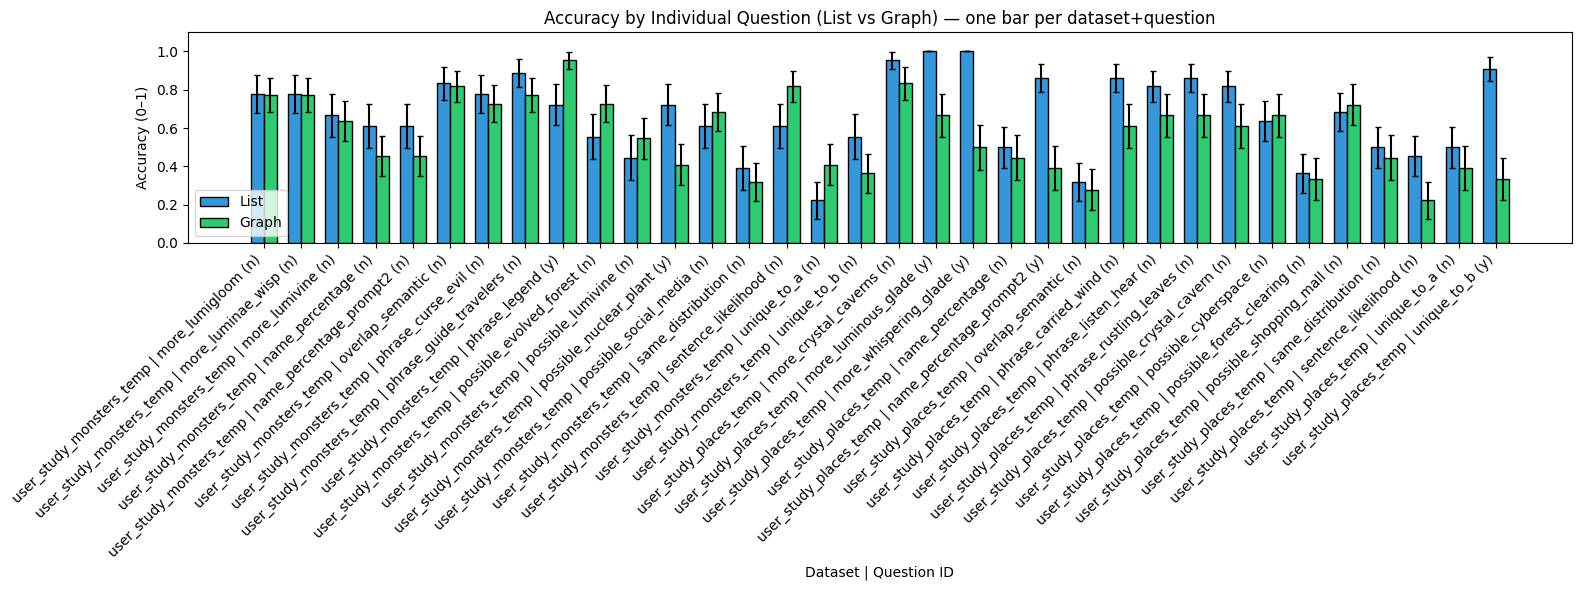

In [28]:
# Per-question bar chart: uses (dataset | questionId) so each bar = one distinct question with its own ground truth
if len(answers_df) == 0:
    print("No data to plot.")
else:
    if 'question_key' not in answers_df.columns:
        answers_df['question_key'] = answers_df['dataset'] + ' | ' + answers_df['questionId']
    plot_df = answers_df[answers_df['questionType'] != 'preference']
    if len(plot_df) == 0:
        print("No scorable questions.")
    else:
        question_keys = sorted(plot_df['question_key'].unique())
        x = np.arange(len(question_keys))
        width = 0.35

        def acc_and_sem(df, qk, cond):
            sub = df[(df['question_key'] == qk) & (df['condition'] == cond)]
            n = len(sub)
            p = sub['correct'].mean() if n > 0 else 0
            return p, sem_proportion(p, n) if n > 0 else 0

        list_acc = [acc_and_sem(plot_df, qk, 'list')[0] for qk in question_keys]
        graph_acc = [acc_and_sem(plot_df, qk, 'graph')[0] for qk in question_keys]
        list_sem = [acc_and_sem(plot_df, qk, 'list')[1] for qk in question_keys]
        graph_sem = [acc_and_sem(plot_df, qk, 'graph')[1] for qk in question_keys]

        p_values_q = [pvalue_graph_vs_list(
            plot_df[(plot_df['question_key'] == qk) & (plot_df['condition'] == 'graph')]['correct'].values,
            plot_df[(plot_df['question_key'] == qk) & (plot_df['condition'] == 'list')]['correct'].values
        ) for qk in question_keys]
        xtick_labels = [f"{qk} (y)" if p < 0.05 else f"{qk} (n)" for qk, p in zip(question_keys, p_values_q)]

        fig, ax = plt.subplots(figsize=(16, 6))
        ax.bar(x - width/2, list_acc, width, yerr=list_sem, label='List', color='#3498db', edgecolor='black', capsize=2)
        ax.bar(x + width/2, graph_acc, width, yerr=graph_sem, label='Graph', color='#2ecc71', edgecolor='black', capsize=2)
        ax.set_xlabel('Dataset | Question ID')
        ax.set_ylabel('Accuracy (0–1)')
        ax.set_title('Accuracy by Individual Question (List vs Graph) — one bar per dataset+question')
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right')
        ax.legend()
        ax.set_ylim(0, 1.1)
        plt.tight_layout()
        plt.show()

### 6.2 Aggregate by Interface (List vs Graph)

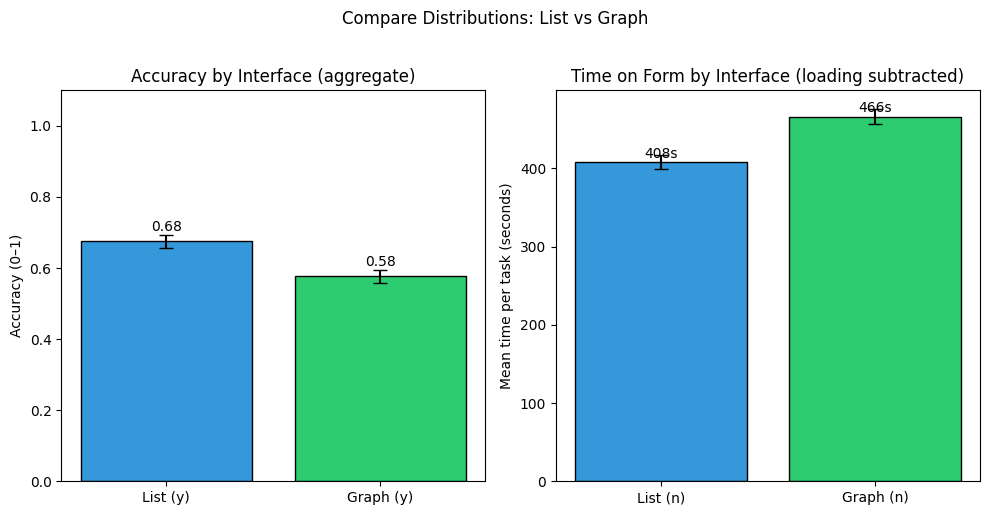

In [29]:
if len(answers_df) == 0:
    print("No data to plot.")
else:
    conditions = ['list', 'graph']
    colors = ['#3498db', '#2ecc71']

    def get_val(summary_df, cond, col, default=0):
        s = summary_df[summary_df['condition'] == cond][col]
        return float(s.iloc[0]) if len(s) > 0 else default

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Accuracy
    ax1 = axes[0]
    acc_data = [get_val(summary, c, 'accuracy', 0) for c in conditions]
    acc_err = [get_val(summary, c, 'sem_accuracy', 0) for c in conditions]
    # (y) = p < 0.05 (significant), (n) = not significant
    labels_acc = [f"List {'(y)' if p_acc < 0.05 else '(n)'}", f"Graph {'(y)' if p_acc < 0.05 else '(n)'}"]
    labels_time = [f"List {'(y)' if p_time < 0.05 else '(n)'}", f"Graph {'(y)' if p_time < 0.05 else '(n)'}"]
    bars1 = ax1.bar(labels_acc, acc_data, yerr=acc_err, color=colors, edgecolor='black', capsize=5)
    ax1.set_ylabel('Accuracy (0–1)')
    ax1.set_title('Accuracy by Interface (aggregate)')
    ax1.set_ylim(0, 1.1)
    for bar, val in zip(bars1, acc_data):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', va='bottom')

    # Time per task (seconds)
    ax2 = axes[1]
    time_data = [get_val(summary, c, 'mean_time_sec', 0) for c in conditions]
    time_err = [get_val(summary, c, 'sem_time_sec', 0) for c in conditions]
    bars2 = ax2.bar(labels_time, time_data, yerr=time_err, color=colors, edgecolor='black', capsize=5)
    ax2.set_ylabel('Mean time per task (seconds)')
    ax2.set_title('Time on Form by Interface (loading subtracted)')
    for bar, val in zip(bars2, time_data):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.0f}s', ha='center', va='bottom')

    plt.suptitle('Compare Distributions: List vs Graph', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

### 6.3 Violin plots (with individual participant dots)

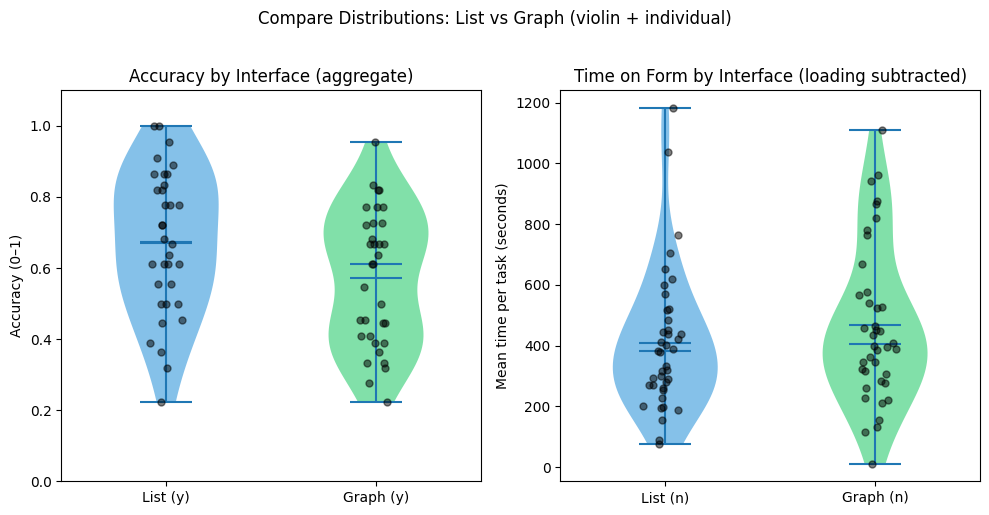

In [30]:
# Violin plots with individual participant dots
if len(answers_df) == 0:
    print("No data to plot.")
else:
    conditions = ['list', 'graph']
    colors = ['#3498db', '#2ecc71']
    labels_violin = [f"List {'(y)' if p_acc < 0.05 else '(n)'}", f"Graph {'(y)' if p_acc < 0.05 else '(n)'}"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Accuracy violin
    ax1 = axes[0]
    acc_data = [list_acc, graph_acc]
    parts = ax1.violinplot(acc_data, positions=[0, 1], showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.6)
    # Overlay individual points with jitter
    np.random.seed(42)
    for i, (vals, pos) in enumerate(zip(acc_data, [0, 1])):
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax1.scatter(pos + jitter, vals, color='black', alpha=0.5, s=25, zorder=3)
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(labels_violin)
    ax1.set_ylabel('Accuracy (0–1)')
    ax1.set_title('Accuracy by Interface (aggregate)')
    ax1.set_ylim(0, 1.1)
    ax1.set_xlim(-0.5, 1.5)

    # Time on form violin
    ax2 = axes[1]
    time_data = [list_time, graph_time]
    labels_time = [f"List {'(y)' if p_time < 0.05 else '(n)'}", f"Graph {'(y)' if p_time < 0.05 else '(n)'}"]
    parts2 = ax2.violinplot(time_data, positions=[0, 1], showmeans=True, showmedians=True)
    for i, pc in enumerate(parts2['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.6)
    for i, (vals, pos) in enumerate(zip(time_data, [0, 1])):
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax2.scatter(pos + jitter, vals, color='black', alpha=0.5, s=25, zorder=3)
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(labels_time)
    ax2.set_ylabel('Mean time per task (seconds)')
    ax2.set_title('Time on Form by Interface (loading subtracted)')
    ax2.set_xlim(-0.5, 1.5)

    plt.suptitle('Compare Distributions: List vs Graph (violin + individual)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

### 6.3.5 Accuracy by participant (barbell chart)

Each participant: two dots (List vs Graph accuracy) connected by a line. X = accuracy, Y = participant.

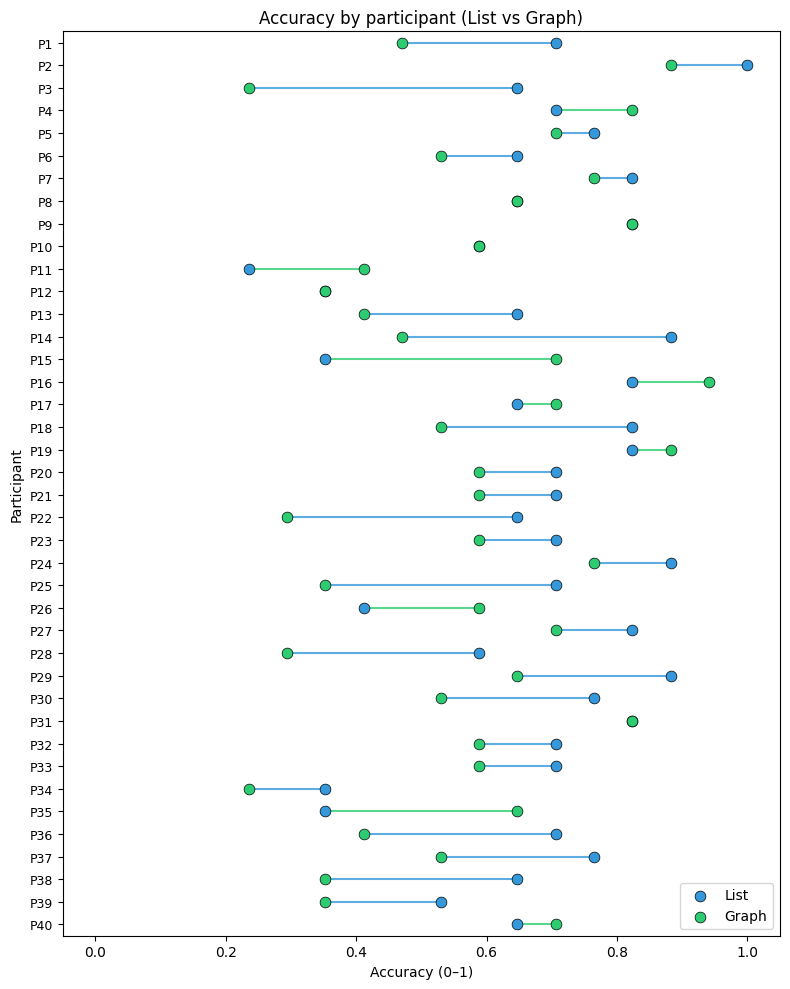

In [31]:
# Barbell chart: each participant gets two dots (List, Graph) connected by a line
if len(answers_df) == 0:
    print("No data to plot.")
else:
    acc_by_pid = answers_df.groupby(['participant_id', 'condition'])['correct'].mean().unstack(fill_value=np.nan)
    if 'list' in acc_by_pid.columns and 'graph' in acc_by_pid.columns:
        plot_df = acc_by_pid[['list', 'graph']].dropna()
        if len(plot_df) > 0:
            n = len(plot_df)
            y_pos = np.arange(n)
            fig, ax = plt.subplots(figsize=(8, max(6, n * 0.25)))
            list_color, graph_color = '#3498db', '#2ecc71'
            for i, (pid, row) in enumerate(plot_df.iterrows()):
                line_color = list_color if row['list'] > row['graph'] else (graph_color if row['graph'] > row['list'] else 'gray')
                ax.plot([row['list'], row['graph']], [i, i], color=line_color, linewidth=1.5, alpha=0.8, zorder=0)
            ax.scatter(plot_df['list'], y_pos, color='#3498db', s=60, label='List', zorder=2, edgecolors='black', linewidths=0.5)
            ax.scatter(plot_df['graph'], y_pos, color='#2ecc71', s=60, label='Graph', zorder=2, edgecolors='black', linewidths=0.5)
            ax.set_xlabel('Accuracy (0–1)')
            ax.set_ylabel('Participant')
            ax.set_yticks(y_pos)
            ax.set_yticklabels([f'P{i+1}' for i in range(n)], fontsize=9)
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.5, n - 0.5)
            ax.legend(loc='lower right')
            ax.set_title('Accuracy by participant (List vs Graph)')
            ax.invert_yaxis()
            plt.tight_layout()
            plt.show()
        else:
            print("No participants with both list and graph accuracy.")
    else:
        print("Need both list and graph conditions.")

### 6.4 Preference vs Time, Accuracy, and Order

Correlation of "Overall, which interface do you prefer?" (1=Graph, 7=List) with:
- **Time**: mean time (min) spent per interface
- **Accuracy**: mean accuracy when using each interface
- **Order**: which interface they used first (Graph first vs List first)

PREFERENCE vs TIME, ACCURACY, ORDER
Preference: 'Overall, which interface do you prefer?' (1=Graph, 7=List)
Participants with complete data: 40

Preference vs Time difference (Graph−List min): r=0.109, p=0.5023
  (Negative r: higher preference for List [7] when spent more time on Graph)

Preference vs Accuracy difference (Graph−List): r=-0.041, p=0.8006
  (Negative r: higher preference for List [7] when more accurate with Graph)

Preference by order (which interface they used first):
  Graph first (n=20): mean preference = 3.95 (lower = prefer Graph)
  List first (n=20): mean preference = 4.00
  t-test: t=-0.07, p=0.9420


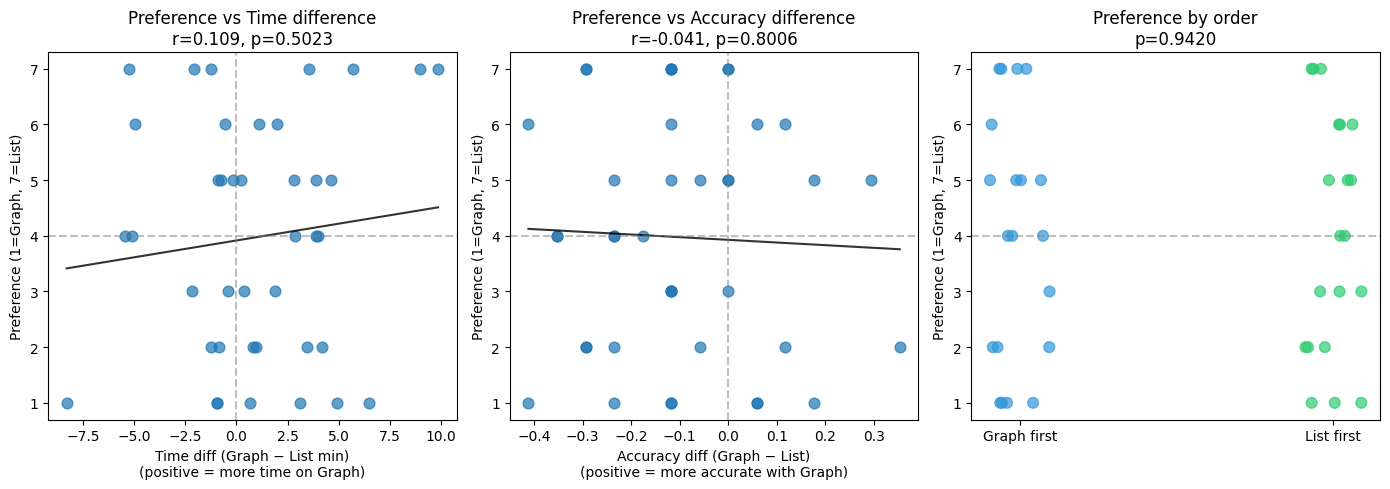

In [32]:
# Preference: "Overall, which interface do you prefer?" (1=Graph, 7=List)
# Load comparing comparisons form and parse prolific_pid from metadata
COMPARING_PATH = DATA_DIR / "user_study_logging - comparing comparisons.csv"
comparisons_df = pd.read_csv(COMPARING_PATH)
metadata_col = [c for c in comparisons_df.columns if "Metadata" in c][0]
pref_col = [c for c in comparisons_df.columns if "Overall" in str(c) and "prefer" in str(c)]
pref_col = pref_col[0] if pref_col else None

def parse_prolific_pid(meta):
    if pd.isna(meta) or not isinstance(meta, str) or meta.strip() == "":
        return None
    if "prolific_pid=" not in meta:
        return None
    for part in meta.split("&"):
        if part.startswith("prolific_pid="):
            return part.split("=", 1)[1].strip()
    return None

pref_df = comparisons_df.copy()
pref_df["prolific_pid"] = pref_df[metadata_col].apply(parse_prolific_pid)
pref_df = pref_df[pref_df["prolific_pid"].notna()].copy()
pref_df["preference"] = pd.to_numeric(pref_df[pref_col], errors="coerce") if pref_col else np.nan
pref_df = pref_df[["prolific_pid", "preference"]].dropna(subset=["preference"]).drop_duplicates("prolific_pid")

# First interface: which interface they used for their first task
first_task = answers_df.groupby("participant_id")["taskNumber"].min().reset_index()
first_task = first_task.merge(
    answers_df[["participant_id", "taskNumber", "condition"]].drop_duplicates(),
    on=["participant_id", "taskNumber"],
)
first_task["first_interface"] = first_task["condition"].map({"list": "List", "graph": "Graph"})

# Time and accuracy by participant (acc_by_pid, time_by_pid already exist)
# time_by_pid is in seconds; convert to minutes for consistency with single_distribution
pid_time = time_by_pid.copy()
pid_time["time_Graph_min"] = pid_time["graph"] / 60
pid_time["time_List_min"] = pid_time["list"] / 60
pid_acc = acc_by_pid.copy()
pid_acc = pid_acc.rename(columns={"graph": "acc_Graph", "list": "acc_List"})

# Add prolific_pid and aggregate by prolific_pid (in case of multiple sessions)
pid_time["prolific_pid"] = pid_time.index.map(lambda x: str(x).split("_")[0] if "_" in str(x) else str(x))
pid_acc["prolific_pid"] = pid_acc.index.map(lambda x: str(x).split("_")[0] if "_" in str(x) else str(x))
pid_time_agg = pid_time.groupby("prolific_pid")[["time_Graph_min", "time_List_min"]].mean().reset_index()
pid_acc_agg = pid_acc.groupby("prolific_pid")[["acc_Graph", "acc_List"]].mean().reset_index()

# Merge preference + first_interface + timing + accuracy
first_task["prolific_pid"] = first_task["participant_id"].map(lambda x: str(x).split("_")[0] if "_" in str(x) else str(x))
pref_corr = pref_df.merge(first_task[["prolific_pid", "first_interface"]].drop_duplicates("prolific_pid"), on="prolific_pid", how="inner")
pref_corr = pref_corr.merge(pid_time_agg, on="prolific_pid", how="inner")
pref_corr = pref_corr.merge(pid_acc_agg, on="prolific_pid", how="inner")
pref_corr["time_diff"] = pref_corr["time_Graph_min"] - pref_corr["time_List_min"]
pref_corr["acc_diff"] = pref_corr["acc_Graph"] - pref_corr["acc_List"]
pref_corr["graph_first"] = (pref_corr["first_interface"] == "Graph").astype(int)

pref_corr = pref_corr.dropna(subset=["preference", "time_diff", "acc_diff"])

print("=" * 70)
print("PREFERENCE vs TIME, ACCURACY, ORDER")
print("Preference: 'Overall, which interface do you prefer?' (1=Graph, 7=List)")
print("=" * 70)
print(f"Participants with complete data: {len(pref_corr)}")
print()

from scipy.stats import pearsonr

r_t, p_t = pearsonr(pref_corr["preference"], pref_corr["time_diff"])
print(f"Preference vs Time difference (Graph−List min): r={r_t:.3f}, p={p_t:.4f}")
print("  (Negative r: higher preference for List [7] when spent more time on Graph)")
print()

r_a, p_a = pearsonr(pref_corr["preference"], pref_corr["acc_diff"])
print(f"Preference vs Accuracy difference (Graph−List): r={r_a:.3f}, p={p_a:.4f}")
print("  (Negative r: higher preference for List [7] when more accurate with Graph)")
print()

g_first = pref_corr[pref_corr["graph_first"] == 1]["preference"]
l_first = pref_corr[pref_corr["graph_first"] == 0]["preference"]
print("Preference by order (which interface they used first):")
print(f"  Graph first (n={len(g_first)}): mean preference = {g_first.mean():.2f} (lower = prefer Graph)")
print(f"  List first (n={len(l_first)}): mean preference = {l_first.mean():.2f}")
t_order, p_order = ttest_ind(g_first, l_first)
print(f"  t-test: t={t_order:.2f}, p={p_order:.4f}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#3498db", "#2ecc71"]  # Graph, List

# 1. Preference vs Time difference
ax = axes[0]
ax.scatter(pref_corr["time_diff"], pref_corr["preference"], alpha=0.7, s=60)
x_t = pref_corr["time_diff"].values
y_t = pref_corr["preference"].values
mask = np.isfinite(x_t) & np.isfinite(y_t)
if np.sum(mask) > 1:
    coeffs_t = np.polyfit(x_t[mask], y_t[mask], 1)
    x_line = np.linspace(x_t.min(), x_t.max(), 100)
    ax.plot(x_line, np.polyval(coeffs_t, x_line), color="black", linewidth=1.5, linestyle="-", alpha=0.8)
ax.axhline(4, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Time diff (Graph − List min)\n(positive = more time on Graph)")
ax.set_ylabel("Preference (1=Graph, 7=List)")
ax.set_title(f"Preference vs Time difference\nr={r_t:.3f}, p={p_t:.4f}")

# 2. Preference vs Accuracy difference
ax = axes[1]
ax.scatter(pref_corr["acc_diff"], pref_corr["preference"], alpha=0.7, s=60)
x_a = pref_corr["acc_diff"].values
y_a = pref_corr["preference"].values
mask = np.isfinite(x_a) & np.isfinite(y_a)
if np.sum(mask) > 1:
    coeffs_a = np.polyfit(x_a[mask], y_a[mask], 1)
    x_line = np.linspace(x_a.min(), x_a.max(), 100)
    ax.plot(x_line, np.polyval(coeffs_a, x_line), color="black", linewidth=1.5, linestyle="-", alpha=0.8)
ax.axhline(4, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Accuracy diff (Graph − List)\n(positive = more accurate with Graph)")
ax.set_ylabel("Preference (1=Graph, 7=List)")
ax.set_title(f"Preference vs Accuracy difference\nr={r_a:.3f}, p={p_a:.4f}")

# 3. Preference by order
ax = axes[2]
np.random.seed(42)
x_jitter = np.where(pref_corr["first_interface"] == "Graph", 0, 1) + np.random.uniform(-0.1, 0.1, len(pref_corr))
plot_colors = [colors[0] if o == "Graph" else colors[1] for o in pref_corr["first_interface"]]
ax.scatter(x_jitter, pref_corr["preference"], c=plot_colors, alpha=0.7, s=60)
ax.axhline(4, color="gray", linestyle="--", alpha=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Graph first", "List first"])
ax.set_ylabel("Preference (1=Graph, 7=List)")
ax.set_title(f"Preference by order\np={p_order:.4f}")

plt.tight_layout()
plt.show()

## 7. Bar Chart: Accuracy by Question Type

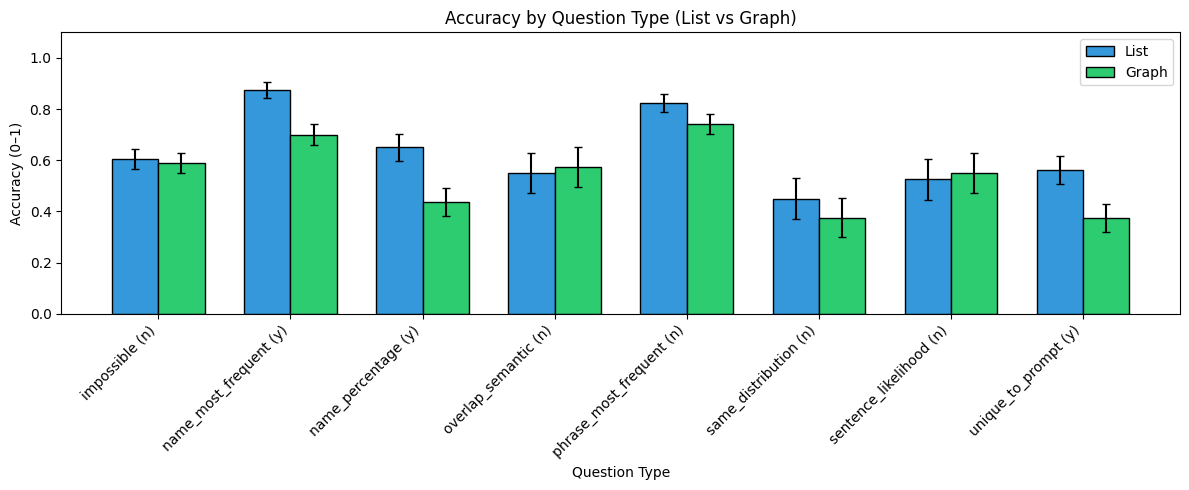

In [33]:
if len(answers_df) == 0:
    print("No data to plot.")
else:
    # Exclude preference (no ground truth)
    plot_df = answers_df[answers_df['questionType'] != 'preference']
    if len(plot_df) == 0:
        print("No scorable questions.")
    else:
        qtypes = plot_df['questionType'].unique()
        qtypes = sorted([q for q in qtypes if q != 'other'])
        if 'other' in plot_df['questionType'].values:
            qtypes.append('other')

        x = np.arange(len(qtypes))
        width = 0.35

        def acc_and_sem(df, qt, cond):
            sub = df[(df['questionType'] == qt) & (df['condition'] == cond)]
            n = len(sub)
            p = sub['correct'].mean() if n > 0 else 0
            return p, sem_proportion(p, n) if n > 0 else 0

        list_acc = [acc_and_sem(plot_df, qt, 'list')[0] for qt in qtypes]
        graph_acc = [acc_and_sem(plot_df, qt, 'graph')[0] for qt in qtypes]
        list_sem = [acc_and_sem(plot_df, qt, 'list')[1] for qt in qtypes]
        graph_sem = [acc_and_sem(plot_df, qt, 'graph')[1] for qt in qtypes]

        # Per-question-type p-values (y = significant, n = not)
        p_values_q = [pvalue_graph_vs_list(
            plot_df[(plot_df['questionType'] == qt) & (plot_df['condition'] == 'graph')]['correct'].values,
            plot_df[(plot_df['questionType'] == qt) & (plot_df['condition'] == 'list')]['correct'].values
        ) for qt in qtypes]
        xtick_labels = [f"{qt} (y)" if p < 0.05 else f"{qt} (n)" for qt, p in zip(qtypes, p_values_q)]

        fig, ax = plt.subplots(figsize=(12, 5))
        bars1 = ax.bar(x - width/2, list_acc, width, yerr=list_sem, label='List', color='#3498db', edgecolor='black', capsize=3)
        bars2 = ax.bar(x + width/2, graph_acc, width, yerr=graph_sem, label='Graph', color='#2ecc71', edgecolor='black', capsize=3)
        ax.set_xlabel('Question Type')
        ax.set_ylabel('Accuracy (0–1)')
        ax.set_title('Accuracy by Question Type (List vs Graph)')
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right')
        ax.legend()
        ax.set_ylim(0, 1.1)
        plt.tight_layout()
        plt.show()

## 8. Timing by Question Type

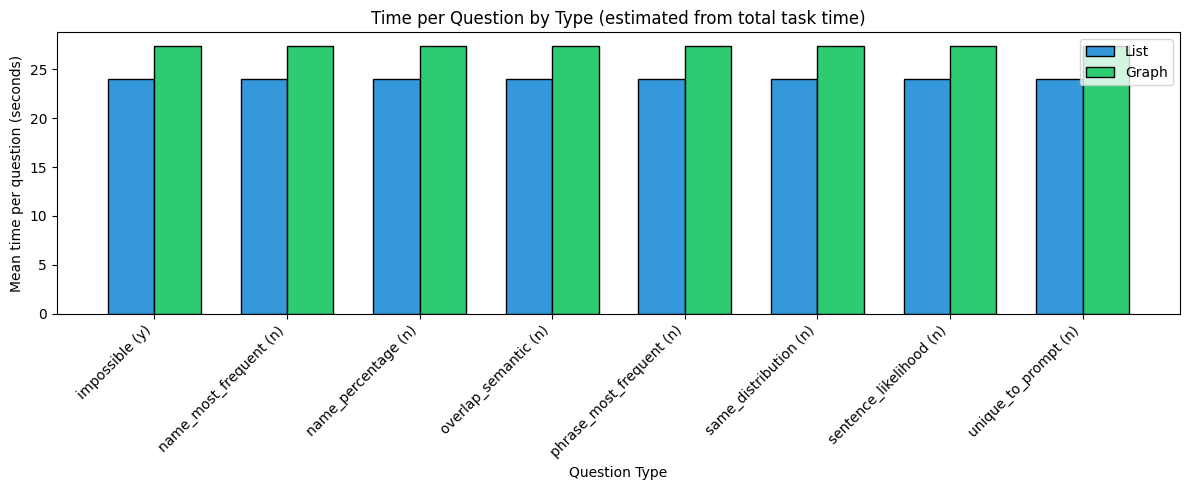

In [34]:
if len(answers_df) == 0:
    print("No data to plot.")
else:
    plot_df = answers_df[answers_df['questionType'] != 'preference']
    if len(plot_df) == 0:
        print("No scorable questions.")
    else:
        qtypes = sorted(plot_df['questionType'].unique())
        qtypes = [q for q in qtypes if q != 'other'] + (['other'] if 'other' in plot_df['questionType'].values else [])

        x = np.arange(len(qtypes))
        width = 0.35

        list_time = [plot_df[(plot_df['questionType'] == qt) & (plot_df['condition'] == 'list')]['timePerQuestionMs'].mean() / 1000 for qt in qtypes]
        graph_time = [plot_df[(plot_df['questionType'] == qt) & (plot_df['condition'] == 'graph')]['timePerQuestionMs'].mean() / 1000 for qt in qtypes]

        # Per-question-type p-values for time (y = significant, n = not)
        p_values_time = [pvalue_graph_vs_list(
            plot_df[(plot_df['questionType'] == qt) & (plot_df['condition'] == 'graph')]['timePerQuestionMs'].values / 1000,
            plot_df[(plot_df['questionType'] == qt) & (plot_df['condition'] == 'list')]['timePerQuestionMs'].values / 1000
        ) for qt in qtypes]
        xtick_labels = [f"{qt} (y)" if p < 0.05 else f"{qt} (n)" for qt, p in zip(qtypes, p_values_time)]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(x - width/2, list_time, width, label='List', color='#3498db', edgecolor='black')
        ax.bar(x + width/2, graph_time, width, label='Graph', color='#2ecc71', edgecolor='black')
        ax.set_xlabel('Question Type')
        ax.set_ylabel('Mean time per question (seconds)')
        ax.set_title('Time per Question by Type (estimated from total task time)')
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right')
        ax.legend()
        plt.tight_layout()
        plt.show()